In [1]:
import sys
sys.path.append("../src")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from torchvision import models

from dataset import gather_samples, stratified_split, CLASSES, get_transforms, IMAGENET_MEAN, IMAGENET_STD

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(CLASSES)

model = models.convnext_tiny(weights=None)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model.load_state_dict(torch.load("convnext_tiny_best.pth", map_location=device))
model = model.to(device)
model.eval()

print("Loaded ConvNeXt-Tiny best checkpoint")

Loaded ConvNeXt-Tiny best checkpoint


In [3]:
# Grad-CAM implementation (works on the last conv/feature block before classifier)
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0]      # (C, H, W)
        activations = self.activations[0]  # (C, H, W)

        weights = gradients.mean(dim=(1, 2))  # (C,)
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam, class_idx


# ConvNeXt-Tiny: last feature block before final norm/pooling
target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)

In [4]:
def load_and_preprocess(img_path):
    img = Image.open(img_path).convert("RGB")
    transform = get_transforms("test")
    tensor = transform(img).unsqueeze(0).to(device)
    return img, tensor


def overlay_cam(img_pil, cam):
    img_resized = np.array(img_pil.resize((224, 224))) / 255.0
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * img_resized + 0.5 * heatmap
    return overlay

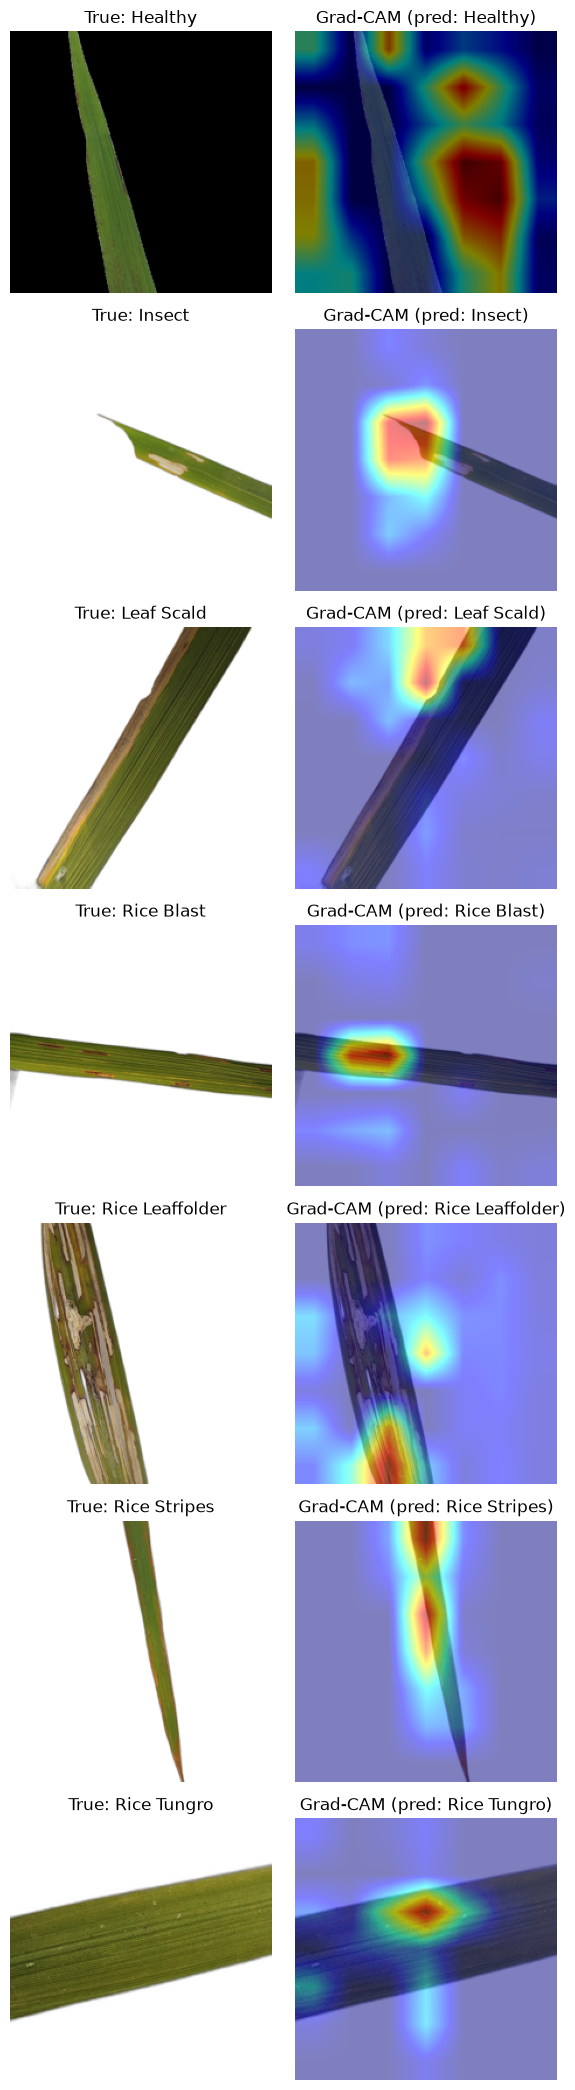

In [5]:
# Pick one sample image per class and show original + Grad-CAM overlay
samples = gather_samples()
_, _, test_set = stratified_split(samples)

one_per_class = {}
for path, label in test_set:
    if label not in one_per_class:
        one_per_class[label] = path
    if len(one_per_class) == NUM_CLASSES:
        break

fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(6, 3*NUM_CLASSES))

for i, (label, path) in enumerate(sorted(one_per_class.items())):
    img_pil, tensor = load_and_preprocess(path)
    cam, pred_idx = gradcam.generate(tensor, class_idx=label)
    overlay = overlay_cam(img_pil, cam)

    axes[i, 0].imshow(img_pil.resize((224, 224)))
    axes[i, 0].set_title(f"True: {CLASSES[label]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"Grad-CAM (pred: {CLASSES[pred_idx]})")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("gradcam_all_classes.png", dpi=150)
plt.show()

In [ ]:
# Optional: Grad-CAM specifically on a few misclassified Rice Stripes samples (weak class)
rice_stripes_idx = CLASSES.index("Rice Stripes")
stripe_samples = [p for p, l in test_set if l == rice_stripes_idx][:4]

fig, axes = plt.subplots(len(stripe_samples), 2, figsize=(6, 3*len(stripe_samples)))

for i, path in enumerate(stripe_samples):
    img_pil, tensor = load_and_preprocess(path)
    cam, pred_idx = gradcam.generate(tensor, class_idx=rice_stripes_idx)
    overlay = overlay_cam(img_pil, cam)

    axes[i, 0].imshow(img_pil.resize((224, 224)))
    axes[i, 0].set_title("Rice Stripes (true)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"pred: {CLASSES[pred_idx]}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("gradcam_rice_stripes.png", dpi=150)
plt.show()